# Conditional Autoregressive: Local ZINC Generation

Use nearby stored molecules as components to generate from a sampled molecule's interpretation graph.

In [1]:
from pathlib import Path
import runpy

roots = (Path.cwd(), *Path.cwd().parents)
candidates = [
    root / relative
    for root in roots
    for relative in (
        "notebooks/_bootstrap.py",
        "repos/abstractgraph-generative/notebooks/_bootstrap.py",
    )
]
bootstrap_path = next((path for path in candidates if path.is_file()), None)
if bootstrap_path is None:
    raise FileNotFoundError("Could not locate notebooks/_bootstrap.py")
runpy.run_path(str(bootstrap_path))

{'__name__': '<run_path>',
 '__doc__': 'Shared bootstrap for notebooks in the AbstractGraph ecosystem.\n\nThis file is intended to be executed from notebooks via ``runpy.run_path``.\nIt resolves the current repo and workspace layout from a range of likely\nstarting directories, prepends available ``src`` directories to ``sys.path``,\nand normalizes the process working directory to the current repo root.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/notebooks/_bootstrap.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjec

In [2]:
from nsppk import NSPPK

from abstractgraph.operators import add, compose, cycle, intersection_edges, name, tree
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator

In [3]:
graphs, _ = ZINCLoader(on_error="skip").load(
    "zinc_250k",
    limit=1500,
    min_node_count=20,
    max_node_count=30,
)
print(f"Loaded {len(graphs)} molecules")

Loaded 1500 molecules


In [4]:
decomposition = compose(
    intersection_edges(),
    add(compose(name("cycle"), cycle()), compose(name("tree"), tree())),
)
generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition,
    nbits=14,
    n_jobs=1,
)
generator.store(
    graphs,
    neighbor_vectorizer=NSPPK(radius=1, distance=4, connector=1, nbits=14),
)

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2830: RuntimeWarning: generate requested n_samples=1 but produced 0 after 32 attempts (budget=32).
  warnings.warn(


Generated 2 molecules from 3 seeds


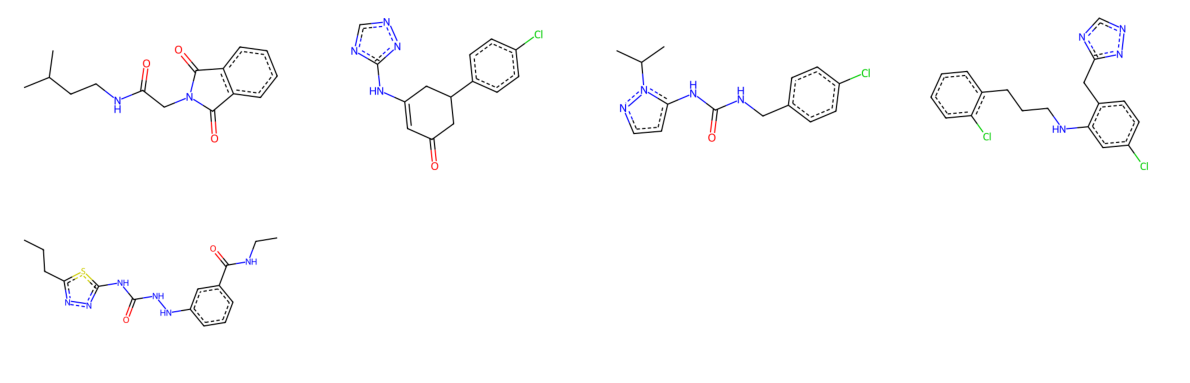

In [5]:
samples = generator.sample(n_samples=3, n_neighbors=30, random_state=0)
print(f"Generated {len(samples)} molecules from {len(generator.last_sampled_indices_)} seeds")
if samples:
    sources = [generator.stored_graphs_[idx] for idx in generator.last_sampled_indices_]
    draw_molecules(sources + samples, n_graphs_per_line=4)
else:
    print("No molecules generated; try a larger neighborhood or training set.")